
# Star Dataset

In [1]:
import pandas as pd
#reading the star data file
data=pd.read_csv('/content/6 class csv.csv')
data.head(5)


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


In [ ]:
#printing the last 5 rows
data[-6:-1]

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
234,21904,748490.0,1130.0,-7.67,5,Blue-white,B
235,38940,374830.0,1356.0,-9.93,5,Blue,O
236,30839,834042.0,1194.0,-10.63,5,Blue,O
237,8829,537493.0,1423.0,-10.73,5,White,A
238,9235,404940.0,1112.0,-11.23,5,White,A


In [ ]:
#removing all nans
data=data.dropna()
data.head()


,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


In [ ]:
#removing duplicates
data=data.drop_duplicates()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.2+ KB


In [ ]:
data.describe()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


In [ ]:
data.groupby('Star type')['Absolute magnitude(Mv)'].mean()

,Absolute magnitude(Mv)
Star type,
0,17.563500
1,12.539975
2,12.582500
3,-0.367425
4,-6.369925
5,-9.654250


In [ ]:
data.sort_values('Star type')

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
188,2778,0.000849,0.1120,19.45,0,Red,M
187,3484,0.000551,0.0998,16.67,0,Red,M
185,2889,0.000352,0.0973,16.93,0,Red,M
184,3453,0.000621,0.0773,17.08,0,Red,M
...,...,...,...,...,...,...,...
175,3614,145000.000000,1553.0000,-7.71,5,Red,M
176,18000,200000.000000,1045.0000,-8.30,5,Blue,O
177,11000,170000.000000,1779.0000,-9.90,5,Blue-white,B
114,3610,132000.000000,1522.0000,-10.86,5,Red,M


In [ ]:
data['Star color'].value_counts()

,count
Star color,
Red,112
Blue,55
Blue-white,26
Blue White,10
yellow-white,8
White,7
Blue white,3
Yellowish White,3
white,3


In [ ]:
data['Star color'].nunique()

19

In [2]:
#making the color into lower case and removing any white space
data['Star color'] = data['Star color'].apply(lambda x:x.lower().strip())

In [3]:
#replacing inconcistent strings with consistent terms
data['Star color'] = data['Star color'].apply(lambda x:x.replace("-", " "))
data['Star color'] = data['Star color'].apply(lambda x:x.replace("yellowish", "yellow"))
data['Star color']= data['Star color'].apply(lambda x:x.replace("whitish", "white"))
data['Star color'] = data['Star color'].apply(lambda x:x.replace("white yellow", "yellow white"))

In [4]:
def cln_clr(c):
    if c in ["orange red", "pale yellow orange", "orange"]:
        return "orange"
    else:
        return c

In [5]:
data['Star color'] = data['Star color'].apply(cln_clr)

In [6]:
data['Star color'].value_counts()

,count
Star color,
red,112
blue,56
blue white,41
white,12
yellow white,12
orange,4
yellow,3


In [ ]:
data['Star color'].nunique()

7

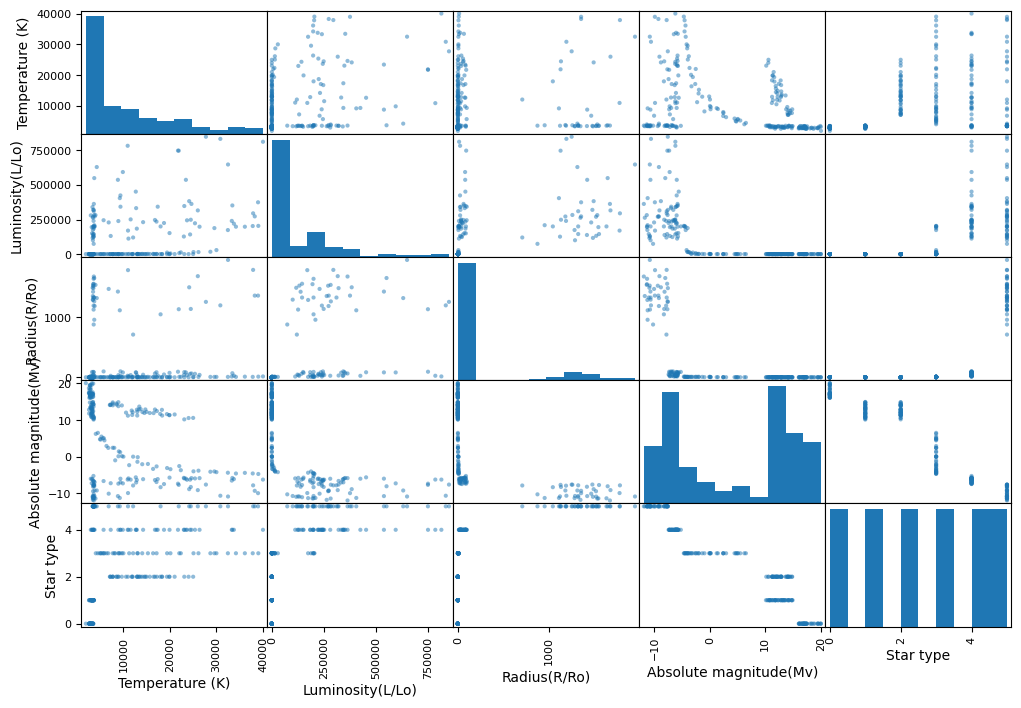

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Instead of using pandas.tools.plotting, use pandas.plotting
from pandas.plotting import scatter_matrix

scatter_matrix(data, figsize=(12, 8))
plt.show()

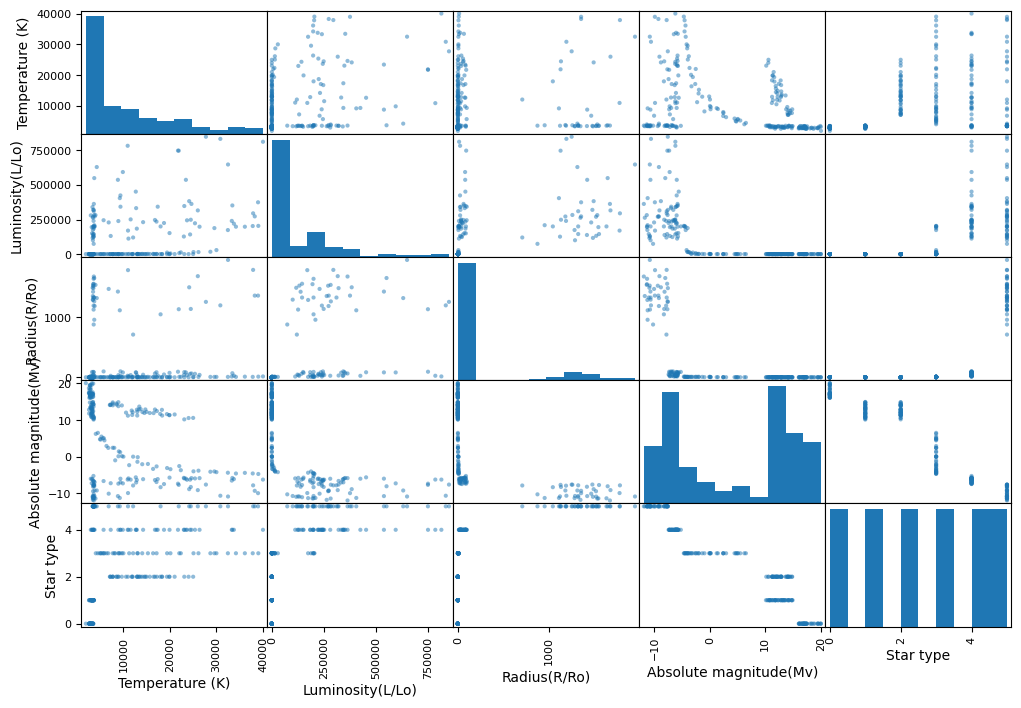

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
Temperature (K),1.000000,0.393404,0.064216,-0.420261,0.411129,NaN,-0.817444
Luminosity(L/Lo),0.393404,1.000000,0.526516,-0.692619,0.676845,NaN,-0.346568
Radius(R/Ro),0.064216,0.526516,1.000000,-0.608728,0.660975,NaN,0.060728
Absolute magnitude(Mv),-0.420261,-0.692619,-0.608728,1.000000,-0.955276,NaN,0.415359
Star type,0.411129,0.676845,0.660975,-0.955276,1.000000,NaN,-0.461116
Star color,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Spectral Class,-0.817444,-0.346568,0.060728,0.415359,-0.461116,NaN,1.000000


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Instead of using pandas.tools.plotting, use pandas.plotting
from pandas.plotting import scatter_matrix

scatter_matrix(data, figsize=(12, 8))
plt.show()

# Convert 'Star color' to numerical representation before calculating correlation
# Create a mapping of colors to numerical values
color_mapping = {
    'red': 1,
    'blue': 2,
    'blue white': 3,
    'white': 4,
    'yellow white': 5,
    'orange':6,
    'yellow':7

}
# Replace color names with numerical values in the DataFrame
data['Star color'] = data['Star color'].map(color_mapping)

# Convert 'Spectral Class' to numerical representation if necessary
# Create a mapping of spectral classes to numerical values if needed
spectral_mapping = {
    'O': 0,
    'B': 1,
    'A': 2,
    'F': 3,
    'G': 4,
    'K': 5,
    'M': 6
}

# Replace spectral class names with numerical values in the DataFrame
data['Spectral Class'] = data['Spectral Class'].map(spectral_mapping)

# Calculate the correlation matrix, include numeric_only=True to handle non-numeric columns
corr_matrix = data.corr(numeric_only=True) # Add numeric_only=True to ignore non-numeric columns
corr_matrix

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

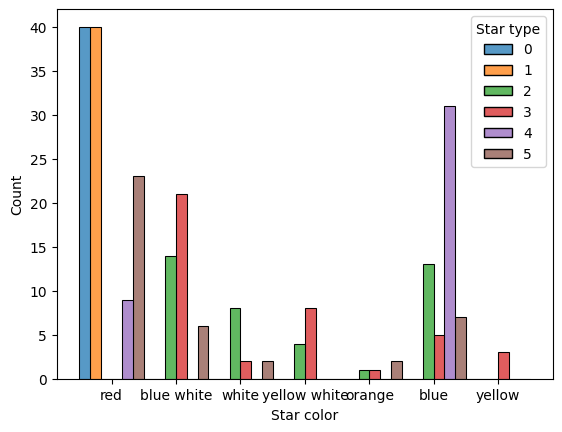


 ---------------------------------------------------------------------------------------------------- 



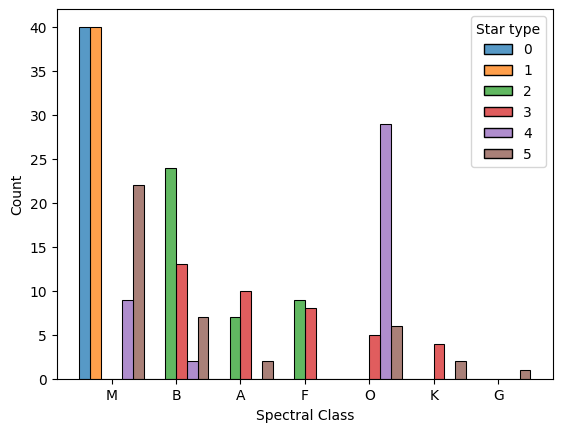


 ---------------------------------------------------------------------------------------------------- 



In [ ]:
for col in data.select_dtypes(include="O").columns:
    sns.histplot(x=data[col], hue=data['Star type'].astype("str"), multiple="dodge")
    plt.show()
    print("\n", "-"*100, "\n")

In [ ]:
data['Star type'].value_counts()

,count
Star type,
0,40
1,40
2,40
3,40
4,40
5,40


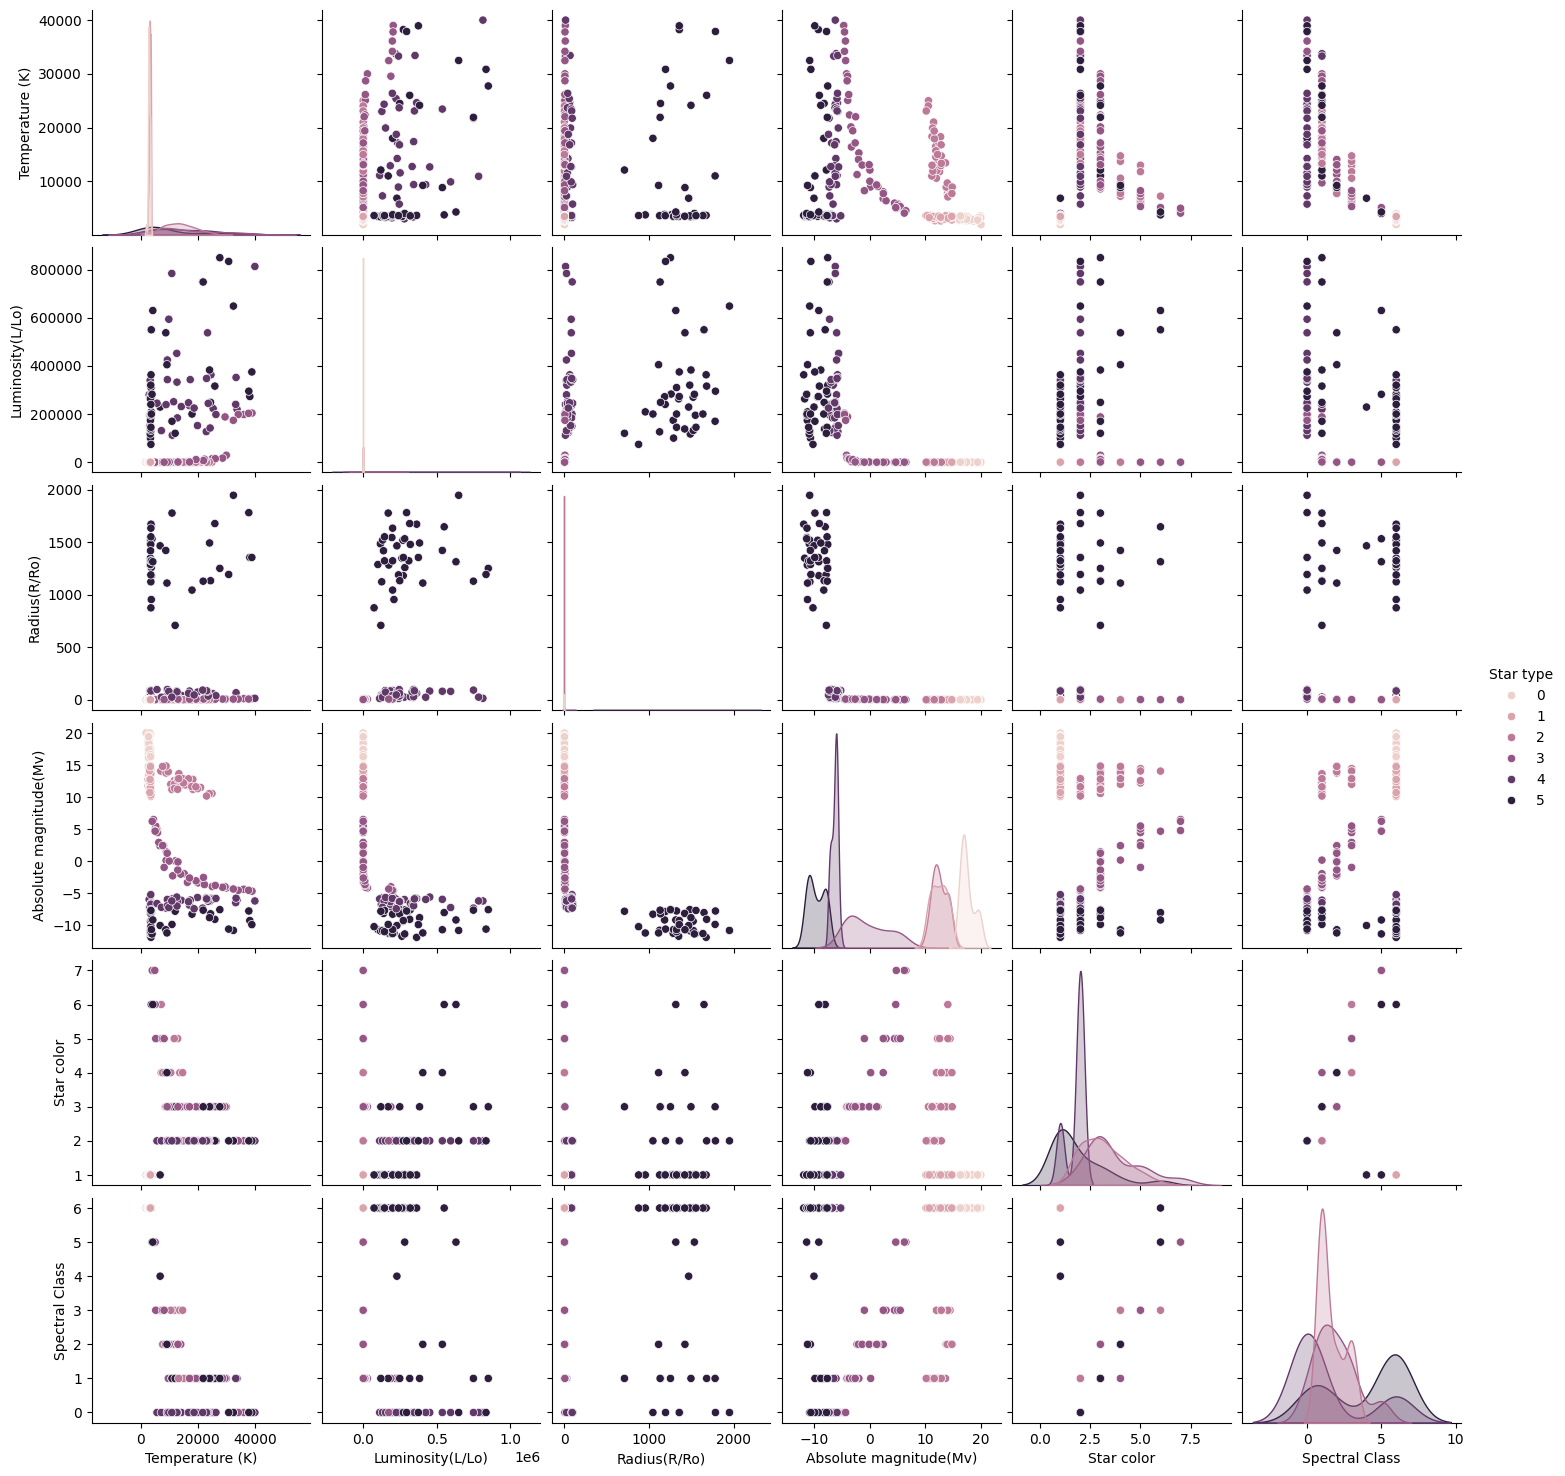

In [ ]:
sns.pairplot(data, hue='Star type')

<Axes: >

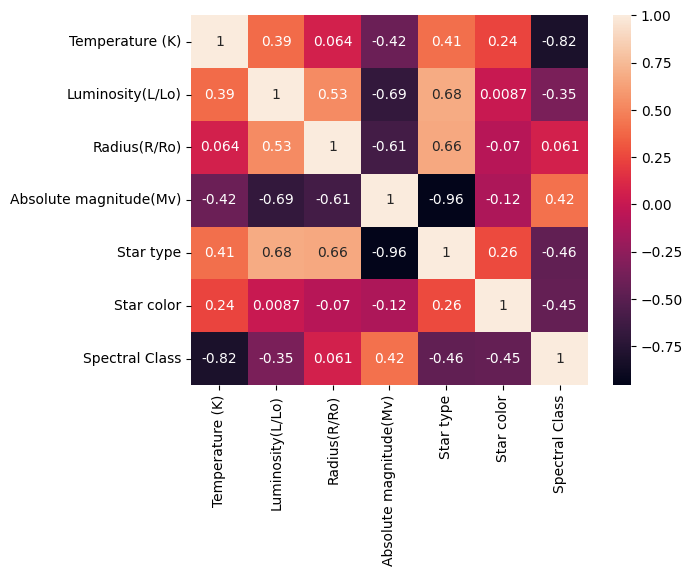

In [ ]:
sns.heatmap(data.corr(), annot=True)

In [4]:
data.copy()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,NaN,6
1,3042,0.000500,0.1542,16.60,0,NaN,6
2,2600,0.000300,0.1020,18.70,0,NaN,6
3,2800,0.000200,0.1600,16.65,0,NaN,6
4,1939,0.000138,0.1030,20.06,0,NaN,6
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,NaN,0
236,30839,834042.000000,1194.0000,-10.63,5,NaN,0
237,8829,537493.000000,1423.0000,-10.73,5,NaN,2
238,9235,404940.000000,1112.0000,-11.23,5,NaN,2


In [5]:
from re import X

import pandas as pd
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (e.g., 80% train, 20% test)
strat_train_set, strat_test_set = train_test_split(data, test_size=0.2, random_state=42)

# Now you can proceed with the rest of your code:
X = strat_test_set.drop('Star type', axis=1)
y = strat_test_set['Star type'].copy()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [7]:
X_train.shape, y_train.shape

((38, 6), (38,))

In [8]:
X_test.shape, y_test.shape

((10, 6), (10,))

In [9]:
print(y_train.dtypes)

int64


In [10]:
y_train = y_train.astype(str)

In [11]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.values.reshape(-1, 1))

In [12]:
# Convert 'Star color' to numerical representation using OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore') # handle_unknown='ignore' for unseen values in test data
star_color_encoded = encoder.fit_transform(data[['Star color']])
star_color_df = pd.DataFrame(star_color_encoded, columns=encoder.get_feature_names_out(['Star color']))
data = data.drop('Star color', axis=1)
data = pd.concat([data, star_color_df], axis=1)

In [13]:
# Split the data into training and testing sets
strat_train_set, strat_test_set = train_test_split(data, test_size=0.2, random_state=42)
X = strat_test_set.drop('Star type', axis=1)
y = strat_test_set['Star type'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [14]:
# Ensure y_train is a Series or 1D array
y_train = y_train.values.ravel()  # Convert to 1D array if necessary

# Now apply LabelBinarizer
from sklearn.preprocessing import LabelBinarizer

encoder = LabelBinarizer()
y_train_cat = encoder.fit_transform(y_train)

In [15]:
X_train.shape, y_train.shape

((38, 7), (38,))

In [16]:
X_test.shape, y_test.shape

((10, 7), (10,))

In [17]:
from sklearn.preprocessing import RobustScaler
scaler= RobustScaler()
X_train[X_train.columns[:4]] = scaler.fit_transform(X_train[X_train.columns[:4]])
X_test[X_test.columns[:4]] = scaler.transform(X_test[X_test.columns[:4]])

In [18]:
# Convert y_train to string type
y_train = y_train.astype(str)

In [19]:
# Encode target variable using LabelBinarizer
encoder = LabelBinarizer()
y_train_cat = encoder.fit_transform(y_train)

In [20]:
from sklearn.linear_model import SGDClassifier
sgd_clf= SGDClassifier()
sgd_clf.fit(X_train, y_train)

SGDClassifier()

In [21]:
from sklearn.model_selection import cross_val_score

In [22]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring='accuracy')

array([0.84615385, 0.84615385, 0.5       ])

In [23]:
from sklearn.ensemble import RandomForestClassifier
forest_clf= RandomForestClassifier()
forest_clf.fit(X_train, y_train)

RandomForestClassifier()

In [24]:
forest_clf.predict_proba(X_test)

array([[0.  , 0.03, 0.07, 0.9 , 0.  , 0.  ],
       [0.47, 0.51, 0.02, 0.  , 0.  , 0.  ],
       [0.  , 0.01, 0.  , 0.  , 0.03, 0.96],
       [0.74, 0.2 , 0.06, 0.  , 0.  , 0.  ],
       [0.  , 0.02, 0.  , 0.01, 0.06, 0.91],
       [0.  , 0.  , 0.  , 0.04, 0.94, 0.02],
       [0.  , 0.  , 0.02, 0.46, 0.52, 0.  ],
       [0.  , 0.03, 0.06, 0.9 , 0.  , 0.01],
       [0.01, 0.01, 0.97, 0.  , 0.  , 0.01],
       [0.97, 0.03, 0.  , 0.  , 0.  , 0.  ]])

In [52]:
cross_val_score(forest_clf,X_train, y_train, cv=3, scoring='accuracy')

array([1.        , 1.        , 0.91666667])

In [53]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring='accuracy')

array([0.69230769, 0.76923077, 0.66666667])

In [54]:
from sklearn.preprocessing import LabelBinarizer



# Ensure y_train is a Series or 1D array
y_train = y_train.ravel()  # Convert to 1D array if necessary

# Now apply LabelBinarizer
encoder = LabelBinarizer()
y_train_cat = encoder.fit_transform(y_train)

# Transform y_test using the same encoder
y_test_cat = encoder.transform(y_test)

# Transform the predictions as well to numerical
y_test_pred_cat = encoder.transform(y_test_pred)


In [55]:
from sklearn.metrics import f1_score
f1_score(y_test_cat, y_test_pred_cat, average='macro')

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.



0.0

In [56]:
train_acc = []
test_acc = []
k_values = list(range(2, 30))

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

k_df = pd.DataFrame({"K":k_values, "Train_acc":train_acc, "Test_acc":test_acc})

In [57]:
import plotly.express as px
px.line(data_frame=k_df, y=["Train_acc", "Test_acc"])

In [58]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsClassifier()

In [59]:
y_test_pred=model.predict(X_test)
y_test_pred

array(['2', '1', '5', '0', '5', '4', '2', '2', '2', '0'], dtype='<U21')

In [60]:
model.score(X_train, y_train)

0.8947368421052632

In [61]:
model.score(X_test, y_test)

0.0